In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [2]:
# TensorFlow GPU memory growth is enabled to avoid allocation issues on some systems.
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled")
    except RuntimeError as e:
        print("Error enabling memory growth:", e)

Memory growth enabled


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_path = '/content/drive/MyDrive/chest_xray/train'
test_path = '/content/drive/MyDrive/chest_xray/test'
val_path = '/content/drive/MyDrive/chest_xray/val'

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32


In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=effnet_preprocess,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=effnet_preprocess
)

training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical' # or 'binary' if you use Dense(1, activation='sigmoid')
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5217 images belonging to 2 classes.
Found 1124 images belonging to 2 classes.


In [6]:
print("Building EfficientNetB3 architecture...")

# Include_top=False drops the final ImageNet classification layer
base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + (3,))

# Freeze the base model to train the classification head first
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(2, activation='softmax')(x) # 2 classes: NORMAL, PNEUMONIA

model_eff = Model(inputs=base_model.input, outputs=predictions)

Building EfficientNetB3 architecture...
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
model_eff.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('efficientnet_b3_pneumonia.keras', save_best_only=True, monitor='val_val_loss')
]

print("Phase 1: Training Classification Head...")
history1 = model_eff.fit(
    training_set,
    validation_data=test_set,
    epochs=15,
    callbacks=callbacks
)

Phase 1: Training Classification Head...
Epoch 1/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 884ms/step - accuracy: 0.9190 - loss: 0.2267

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


164/164 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.9191 - loss: 0.2263 - val_accuracy: 0.9244 - val_loss: 0.2577 - learning_rate: 0.0010
Epoch 2/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 140s 855ms/step - accuracy: 0.9560 - loss: 0.1197 - val_accuracy: 0.9475 - val_loss: 0.1615 - learning_rate: 0.0010
Epoch 3/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 135s 824ms/step - accuracy: 0.9678 - loss: 0.0941 - val_accuracy: 0.9448 - val_loss: 0.1532 - learning_rate: 0.0010
Epoch 4/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.9581 - loss: 0.1086 - val_accuracy: 0.9368 - val_loss: 0.1989 - learning_rate: 0.0010
Epoch 5/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.9727 - loss: 0.0775
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
164/164 ━━━━━━━━━━━━━━━━━━━━ 138s 838ms/step - accuracy: 0.9727 - loss: 0.0775 - val_accuracy: 0.9511 - val_loss: 0.1826 - learning_rate: 0.0010
Epoch 6/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 137s 836ms/step - accuracy: 0.9741 - loss: 0

In [16]:
print("Phase 2: Fine-Tuning deep layers...")

# Unfreeze the last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a very low learning rate
model_eff.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model_eff.fit(
    training_set,
    validation_data=test_set,
    epochs=30, # Continue training
    callbacks=callbacks
)

Phase 2: Fine-Tuning deep layers...
Epoch 1/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.9787 - loss: 0.0578 - val_accuracy: 0.9520 - val_loss: 0.1480 - learning_rate: 1.0000e-05
Epoch 2/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 148s 906ms/step - accuracy: 0.9779 - loss: 0.0609 - val_accuracy: 0.9484 - val_loss: 0.1542 - learning_rate: 1.0000e-05
Epoch 3/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.9821 - loss: 0.0480
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
164/164 ━━━━━━━━━━━━━━━━━━━━ 143s 871ms/step - accuracy: 0.9821 - loss: 0.0481 - val_accuracy: 0.9484 - val_loss: 0.1536 - learning_rate: 1.0000e-05
Epoch 4/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 145s 881ms/step - accuracy: 0.9811 - loss: 0.0479 - val_accuracy: 0.9484 - val_loss: 0.1556 - learning_rate: 5.0000e-06
Epoch 5/30
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.9802 - loss: 0.0476
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
164/164 ━━

In [18]:
model_eff.save('efficientnet_b3_pneumonia_final2.h5')


In [19]:
print("Evaluating Model on Test Set...")
y_pred_proba = model_eff.predict(test_set)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_set.classes

# Get class names from the test_set in the correct order
class_indices = test_set.class_indices
class_names = [None] * len(class_indices)
for name, index in class_indices.items():
    class_names[index] = name

print(classification_report(y_true, y_pred, target_names=test_set.class_indices.keys(),digits=5))

Evaluating Model on Test Set...
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 645ms/step
              precision    recall  f1-score   support

      NORMAL    0.97264   0.90092   0.93541       434
   PNEUMONIA    0.94044   0.98406   0.96176       690

    accuracy                        0.95196      1124
   macro avg    0.95654   0.94249   0.94858      1124
weighted avg    0.95287   0.95196   0.95158      1124



Plotting Confusion Matrix...


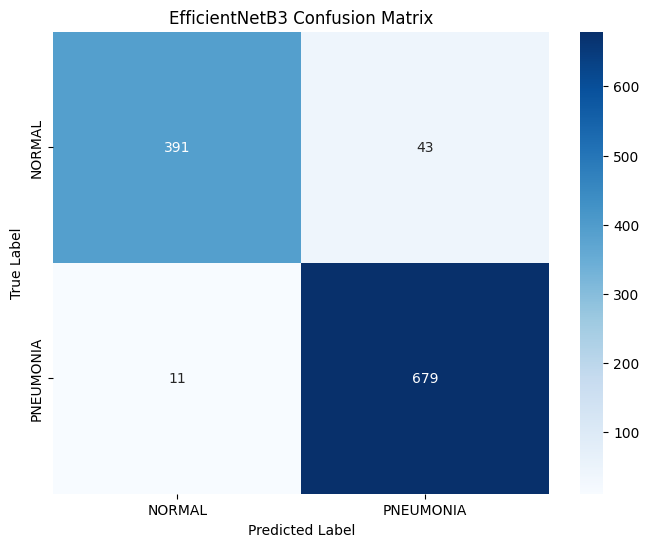

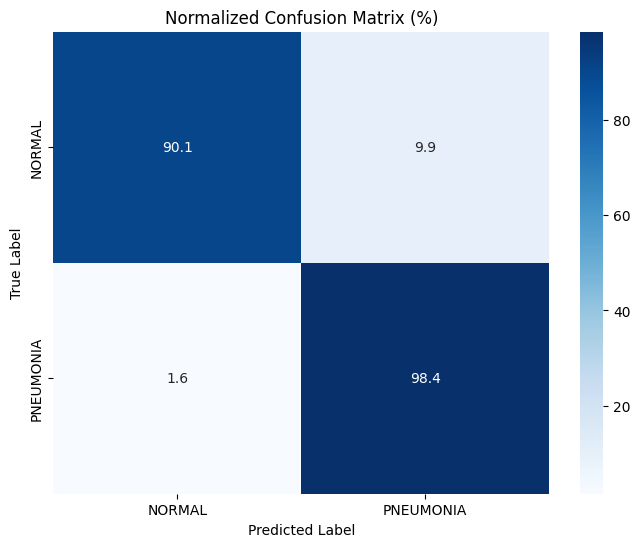

Plotting Training History...


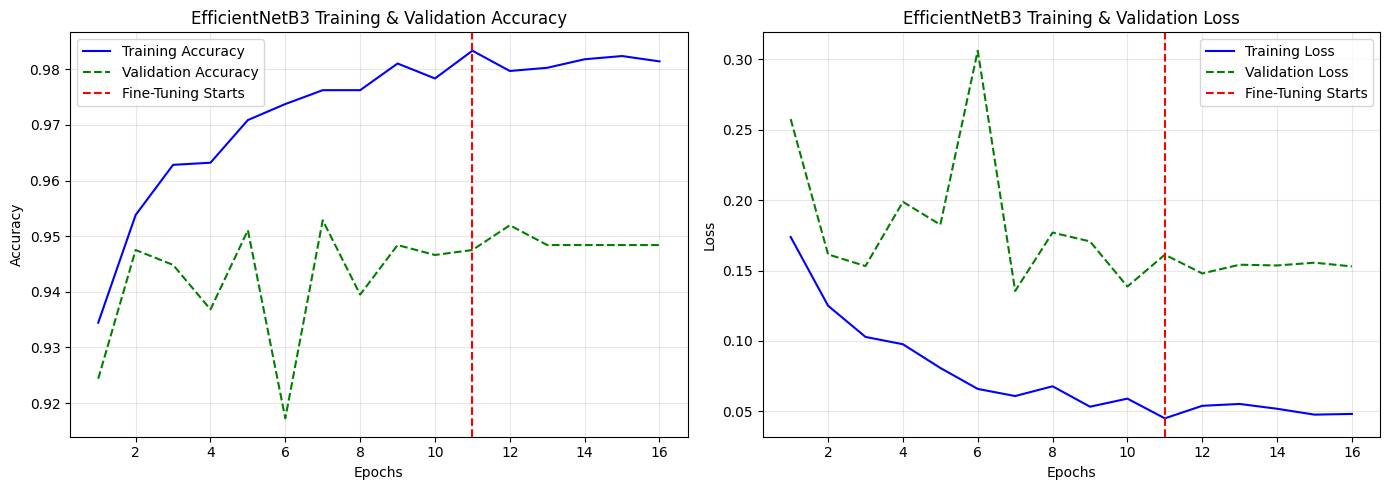

Plotting ROC Curves...


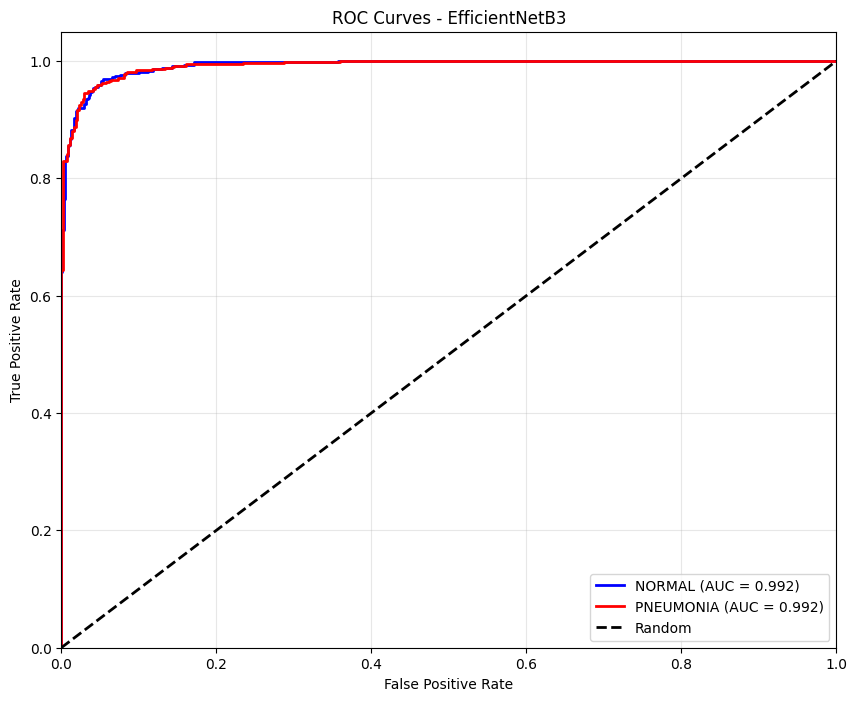

Plotting Precision-Recall Curves...


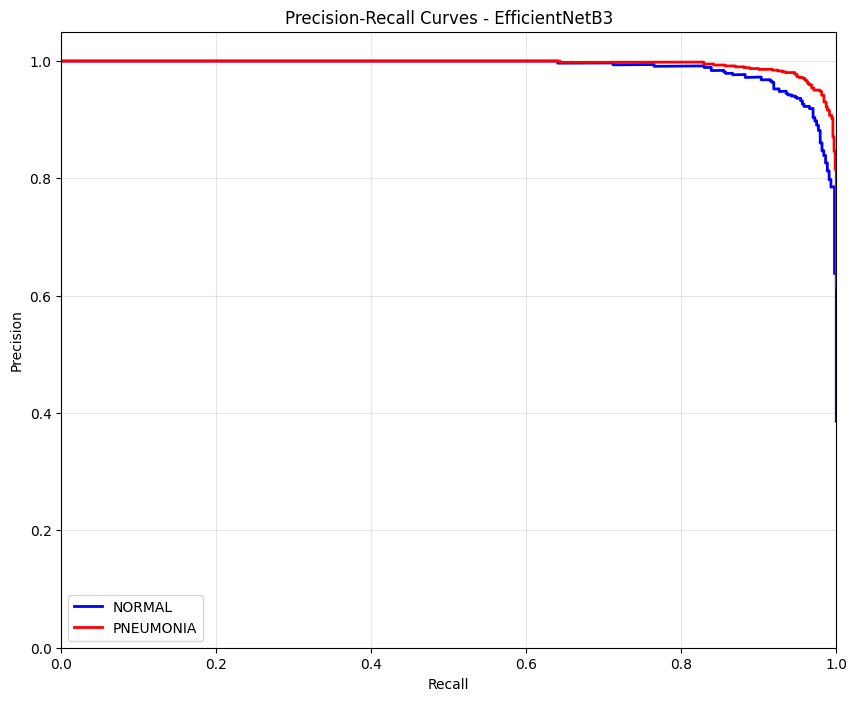

✅ All EfficientNet evaluations successfully plotted and saved to the 'results' folder!


In [20]:
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

os.makedirs('results', exist_ok=True)

# 1. Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('EfficientNetB3 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('results/efficientnet_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Normalized Confusion Matrix
plt.figure(figsize=(8, 6))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized * 100, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (%)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('results/efficientnet_confusion_matrix_norm.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Training History Curves (combining both phases)
print("Plotting Training History...")
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss'] + history2.history['loss']
val_loss = history1.history['val_loss'] + history2.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'g--', label='Validation Accuracy')
plt.axvline(x=len(history1.history['accuracy']), color='r', linestyle='--', label='Fine-Tuning Starts')
plt.title('EfficientNetB3 Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'g--', label='Validation Loss')
plt.axvline(x=len(history1.history['loss']), color='r', linestyle='--', label='Fine-Tuning Starts')
plt.title('EfficientNetB3 Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/efficientnet_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. ROC Curves
print("Plotting ROC Curves...")
plt.figure(figsize=(10, 8))
colors = ['blue', 'red']
for i, (class_name, color) in enumerate(zip(class_names, colors)):
    y_true_bin = (y_true == i).astype(int)
    fpr, tpr, _ = roc_curve(y_true_bin, y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - EfficientNetB3')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('results/efficientnet_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Precision-Recall Curves
print("Plotting Precision-Recall Curves...")
plt.figure(figsize=(10, 8))
for i, (class_name, color) in enumerate(zip(class_names, colors)):
    y_true_bin = (y_true == i).astype(int)
    precision, recall, _ = precision_recall_curve(y_true_bin, y_pred_proba[:, i])
    plt.plot(recall, precision, color=color, lw=2, label=f'{class_name}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - EfficientNetB3')
plt.legend(loc="lower left")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, alpha=0.3)
plt.savefig('results/efficientnet_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ All EfficientNet evaluations successfully plotted and saved to the 'results' folder!")